# Experiment 01.01 — BTW Sandpile SOC Signature Validation

Validate diagnostic functions against the Bak-Tang-Wiesenfeld sandpile, the canonical SOC system. The goal is to confirm that our signature detection tools correctly identify SOC properties in a system where criticality is guaranteed by construction.

**Reference design:** [`work/experiments/validation/01_sandpile.md`](experiments/validation/01_sandpile.md)

**Implementation:** [`work/experiments/validation/sandpile.jl`](experiments/validation/sandpile.jl), [`work/experiments/validation/diagnostics.jl`](experiments/validation/diagnostics.jl)

## Setup

In [1]:
include("experiments/validation/load_validation.jl")

using DataFrames
using Statistics
using Printf

## Mode

Two modes controlled by `MODE`:

- `:explore` — small in-kernel runs for smoke tests, burn-in diagnostics, and iterating on new signature functions. One seed at small L. Memory stays bounded; the notebook is safe to restart.
- `:analyze` — load pre-computed ensemble Arrow files produced by `run_btw_ensemble` in the headless Julia container. Sections 3+ work against pooled data from many seeds per L.

Large ensemble production is **not** done in this notebook — that runs in the headless Julia container (see [WORKFLOW.md](experiments/validation/WORKFLOW.md)).

In [2]:
# :explore for in-kernel iteration; :analyze to load ensemble from disk.
MODE = :explore

# For :analyze mode — which L values to load from disk.
# For :explore mode — which L values to simulate (one seed each at small L).
L_values = MODE == :analyze ? [128, 256, 512, 1024] : [64]

# Shared parameter.
N_record = MODE == :explore ? 50_000 : 200_000

# Where the ensemble Arrow files live (produced by run_btw_ensemble).
ENSEMBLE_DATA_DIR = "data/exp01_01"

println("Mode: \$MODE")
println("L values: \$L_values")


Mode: full
L values: [128, 256, 512, 1024]
  L=128 : 40 seed(s)
  L=256 : 30 seed(s)
  L=512 : 20 seed(s)
  L=1024 : 10 seed(s)


## 1. Smoke test — small lattice

Run a tiny BTW sandpile to verify the simulator works end-to-end before doing anything expensive.

In [3]:
smoke = btw_sandpile(32; N_transient=10_000, N_record=10_000, seed=1)

smoke_sizes = avalanche_sizes(smoke.catalog)

println("Smoke test — L=32, N_record=10,000:")
@printf("  Mean lattice height: %.3f (expected ~2.125 for BTW)\n", mean(smoke.final_height))
@printf("  Non-empty avalanches: %d / %d\n", length(smoke_sizes), length(smoke.catalog))
@printf("  Mean avalanche size:  %.2f\n", mean(smoke_sizes))
@printf("  Max avalanche size:   %d\n", maximum(smoke_sizes))

Smoke test — L=32, N_record=10,000:
  Mean lattice height: 2.080 (expected ~2.125 for BTW)
  Non-empty avalanches: 4216 / 10000
  Mean avalanche size:  95.46
  Max avalanche size:   2137


## 1b. Burn-in convergence trace

With `:empty` initial condition, there is no clean "now at criticality" signal — only convergence diagnostics. We monitor:

- **`mean_z`** should climb monotonically and plateau at **17/8 = 2.125** (Dhar 1999, exact stationary value for 2D BTW).
- **`dissipation_rate_recent`** should rise and plateau at **1.0** (one grain leaves per grain added at steady state).
- **`mean_avalanche_size_recent`** should stabilize.

Run once per lattice size to choose an appropriate `N_transient` for production runs.

In [4]:
trace_L = 64
trace = btw_burnin_trace(trace_L;
                         N_grains=10 * trace_L * trace_L,
                         log_every=1000,
                         seed=1)
show(DataFrame(trace), allrows=true, allcols=true)

40×5 DataFrame
 Row │ step   mean_z    cumulative_dissipation  dissipation_rate_recent  mean_avalanche_size_recent 
     │ Int64  Float64   Int64                   Float64                  Float64                    
─────┼──────────────────────────────────────────────────────────────────────────────────────────────
   1 │  1000  0.244141                       0                    0.0                         0.001
   2 │  2000  0.488281                       0                    0.0                         0.004
   3 │  3000  0.732422                       0                    0.0                         0.025
   4 │  4000  0.976074                       2                    0.002                       0.061
   5 │  5000  1.21802                       11                    0.009                       0.148
   6 │  6000  1.45874                       25                    0.014                       0.268
   7 │  7000  1.69775                       46                    0.021           

**Reading the table:** find the step where `mean_z` first exceeds ~2.10 and stays there, and where `dissipation_rate_recent` is consistently near 1.0. That step is the empirical N_transient for this lattice size. Round up for safety. The default `10 × L²` used below is conservative.

In [5]:
# Optional: same trace from :overloaded initial condition for comparison.
# Should converge much faster (the initial cascade does most of the work).
trace_overloaded = btw_burnin_trace(trace_L;
                                    N_grains=2 * trace_L * trace_L,
                                    log_every=1000,
                                    initial_condition=:overloaded,
                                    seed=1)
DataFrame(trace_overloaded)

Row,step,mean_z,cumulative_dissipation,dissipation_rate_recent,mean_avalanche_size_recent
,Int64,Float64,Int64,Float64,Float64
1,1000,2.11182,988,0.988,152.727
2,2000,2.10107,2032,1.044,156.843
3,3000,2.10107,3032,1.0,157.67
4,4000,2.09644,4051,1.019,152.64
5,5000,2.10083,5033,0.982,154.093
6,6000,2.10327,6023,0.99,149.048
7,7000,2.09595,7053,1.03,154.394
8,8000,2.12036,7953,0.9,138.868


## 1c. Adaptive burn-in

Rather than hardcoding `N_transient` as a multiple of L², detect steady state from the observed signals: `mean_z` plateau + `dissipation_rate` near 1.0. This works for any L and any initial condition.

Convergence criterion (default):
- Range of `mean_z` over last 5 check windows < 0.02
- Mean of `dissipation_rate_recent` over last 5 windows in [0.9, 1.1]

Returns the burn-in trace so you can see when and how convergence happened.

In [6]:
# Empty start — should converge around step ~10K for L=64
adaptive_empty = btw_sandpile_adaptive(64;
                                       N_record=50_000,
                                       initial_condition=:empty,
                                       seed=42)
@printf("Empty start:      converged=%s  burnin=%d grains\n",
        adaptive_empty.converged, adaptive_empty.n_burnin_grains)

# Overloaded start — should converge immediately
adaptive_over = btw_sandpile_adaptive(64;
                                     N_record=50_000,
                                     initial_condition=:overloaded,
                                     seed=42)
@printf("Overloaded start: converged=%s  burnin=%d grains\n",
        adaptive_over.converged, adaptive_over.n_burnin_grains)

Empty start:      converged=true  burnin=14000 grains
Overloaded start: converged=true  burnin=5000 grains


In [7]:
# Inspect the burn-in trace to see the convergence path
show(DataFrame(adaptive_empty.burnin_trace), allrows=true, allcols=true)

14×5 DataFrame
 Row │ step   mean_z    cumulative_dissipation  dissipation_rate_recent  mean_avalanche_size_recent 
     │ Int64  Float64   Int64                   Float64                  Float64                    
─────┼──────────────────────────────────────────────────────────────────────────────────────────────
   1 │  1000  0.244141                       0                    0.0                         0.001
   2 │  2000  0.488281                       0                    0.0                         0.005
   3 │  3000  0.732178                       1                    0.001                       0.027
   4 │  4000  0.974854                       7                    0.006                       0.08
   5 │  5000  1.21729                       14                    0.007                       0.152
   6 │  6000  1.45728                       31                    0.017                       0.337
   7 │  7000  1.69702                       49                    0.018            

## 2. Populate `results`

Two paths — MODE-gated:

- `:explore` runs `btw_sandpile_adaptive` live for one seed at each L in `L_values`. Builds a minimal `results` dict with a single per-seed entry per L, suitable for testing the analysis cells below on small data.
- `:analyze` loads pre-computed Arrow files via `load_ensemble`. Each `results[L]` carries pooled summary statistics across many seeds plus per-seed DataFrames for ensemble analysis.

Both paths populate the same fields so downstream cells work uniformly:
- `.sizes`, `.durations`, `.areas`, `.extents` — vectors across all avalanches
- `.n_seeds` — seed count
- `.summaries` — per-avalanche DataFrame with a `seed` column
- `:analyze` adds `.micro`, `.diagnostics`, and optional `.final_height`
- `:explore` adds `.catalog` with raw `AvalancheRecord`s (enables mid-iteration prototyping of new diagnostics that need `wave_profile`)

In [8]:
results = Dict{Int, NamedTuple}()

if MODE == :explore
    for L in L_values
        @printf("L=%d (explore, 1 seed) record=%d ... ", L, N_record)
        t = @elapsed res = btw_sandpile_adaptive(L; N_record=N_record, seed=1)
        catalog = res.catalog
        sizes_v = avalanche_sizes(catalog; exclude_empty=false)
        durs_v = avalanche_durations(catalog; exclude_empty=false)
        areas_v = avalanche_areas(catalog; exclude_empty=false)
        exts_v = avalanche_extents(catalog; exclude_empty=false)
        summaries = DataFrame(
            L = fill(L, length(catalog)),
            seed = fill(1, length(catalog)),
            idx = 1:length(catalog),
            size = sizes_v,
            duration = durs_v,
            area = areas_v,
            max_extent = exts_v,
        )
        results[L] = (
            catalog = catalog,
            final_height = res.final_height,
            sizes = sizes_v,
            durations = durs_v,
            areas = areas_v,
            extents = exts_v,
            summaries = summaries,
            n_seeds = 1,
            per_seed = [res],
            source = :explore,
        )
        @printf("done in %.1fs  mean_z=%.3f  burnin=%d\n",
                t, mean(res.final_height), res.n_burnin_grains)
    end

elseif MODE == :analyze
    for L in L_values
        @printf("L=%d loading from %s ... ", L, ENSEMBLE_DATA_DIR)
        t = @elapsed loaded = load_ensemble(ENSEMBLE_DATA_DIR, L)
        results[L] = (
            catalog = nothing,  # wave_profiles discarded in streaming pipeline
            final_height = isnothing(loaded.heights) ? nothing :
                           reconstruct_height_field(loaded.heights),
            sizes = Int64.(loaded.summaries.size),
            durations = Int32.(loaded.summaries.duration),
            areas = Int32.(loaded.summaries.area),
            extents = Float32.(loaded.summaries.max_extent),
            summaries = loaded.summaries,
            diagnostics = loaded.diagnostics,
            micro = loaded.micro,
            n_seeds = nrow(loaded.diagnostics),
            raw_waves = loaded.raw_waves,
            source = :analyze,
        )
        @printf("done in %.1fs  %d seeds  %d avalanches\n",
                t, results[L].n_seeds, length(results[L].sizes))
    end

else
    error("MODE must be :explore or :analyze, got :\$MODE")
end

nothing


L=128: n_seeds=40  record=200000 per seed
  seed=1: 8.4s  burnin=40000  converged=true  mean_z=2.118
  seed=2: 8.5s  burnin=40000  converged=true  mean_z=2.113
  seed=3: 8.4s  burnin=40000  converged=true  mean_z=2.111
  seed=4: 8.2s  burnin=40000  converged=true  mean_z=2.113
  seed=5: 8.5s  burnin=40000  converged=true  mean_z=2.117
  seed=6: 8.5s  burnin=40000  converged=true  mean_z=2.115
  seed=7: 8.8s  burnin=40000  converged=true  mean_z=2.110
  seed=8: 8.3s  burnin=40000  converged=true  mean_z=2.112
  seed=9: 9.1s  burnin=40000  converged=true  mean_z=2.115
  seed=10: 9.1s  burnin=40000  converged=true  mean_z=2.115
  seed=11: 8.4s  burnin=40000  converged=true  mean_z=2.118
  seed=12: 9.1s  burnin=40000  converged=true  mean_z=2.111
  seed=13: 8.6s  burnin=40000  converged=true  mean_z=2.109
  seed=14: 8.9s  burnin=40000  converged=true  mean_z=2.116
  seed=15: 9.5s  burnin=40000  converged=true  mean_z=2.116
  seed=16: 8.9s  burnin=40000  converged=true  mean_z=2.114
  seed=

### Catalog summary

In [9]:
summary_rows = NamedTuple[]
for L in L_values
    r = results[L]
    nonempty_mask = r.sizes .> 0
    nonempty_sizes = r.sizes[nonempty_mask]
    nonempty_durations = r.durations[nonempty_mask]
    mean_h = isnothing(r.final_height) ? NaN : mean(r.final_height)
    push!(summary_rows, (
        L = L,
        n_seeds = r.n_seeds,
        n_recorded = length(r.sizes),
        n_nonempty = length(nonempty_sizes),
        mean_size = isempty(nonempty_sizes) ? NaN : mean(nonempty_sizes),
        median_size = isempty(nonempty_sizes) ? NaN : median(nonempty_sizes),
        max_size = isempty(nonempty_sizes) ? 0 : maximum(nonempty_sizes),
        mean_duration = isempty(nonempty_durations) ? NaN : mean(nonempty_durations),
        max_duration = isempty(nonempty_durations) ? 0 : maximum(nonempty_durations),
        mean_height = mean_h,
    ))
end
DataFrame(summary_rows)


Row,L,n_recorded,n_nonempty,mean_size,median_size,max_size,mean_duration,max_duration,mean_height
,Int64,Int64,Int64,Float64,Float64,Int64,Float64,Int64,Float64
1,128,8000000,3525644,1347.64,42.0,161642,79.5227,3806,2.11157
2,256,6000000,2661410,5271.47,53.0,1126872,158.599,15590,2.11858
3,512,4000000,1778460,20877.6,62.0,6839870,314.657,37847,2.1216
4,1024,2000000,891488,82969.5,66.0,49746439,616.962,136071,2.12367


## 3. Signature 1 — Power-law avalanche size distribution

Expected: tau_s ≈ 1.2 (effective; BTW exhibits multiscaling per Tebaldi et al. 1999, so a single exponent is approximate).

In [10]:
pl_rows = NamedTuple[]
for L in L_values
    sizes = Float64.(filter(>(0), results[L].sizes))
    fit = fit_power_law(sizes)
    cmp = compare_power_law_exponential(sizes, fit.xmin, fit.alpha)
    push!(pl_rows, (
        L = L,
        xmin = fit.xmin,
        alpha = fit.alpha,
        sigma_alpha = fit.sigma_alpha,
        ks_distance = fit.ks_distance,
        n_tail = fit.n_tail,
        ll_ratio_pl_vs_exp = cmp.log_likelihood_ratio,
    ))
end
DataFrame(pl_rows)


Row,L,xmin,alpha,sigma_alpha,ks_distance,n_tail,ll_ratio_pl_vs_exp
,Int64,Float64,Float64,Float64,Float64,Int64,Float64
1,128,5998.0,2.40552,0.00301967,0.0637786,216648,-2362.95
2,256,21276.0,2.14634,0.00285833,0.0652017,160842,4005.67
3,512,82227.0,1.99547,0.0032419,0.0662051,94288,6948.07
4,1024,3.0,1.19941,0.00023145,0.0624218,742333,2.97105e6


### 3a. Visualize P(s) to identify the scaling regime

Clauset's auto-xmin search landed in the finite-size cutoff region. Plotting log-binned P(s) on log-log reveals the three regimes:

- **Small s** (< 10ish): deviations due to lattice discretization
- **Middle s** (~10-1000 for L=64): the scaling regime where tau_s ≈ 1.2 lives
- **Large s** (upper tail): finite-size cutoff where the distribution curves down

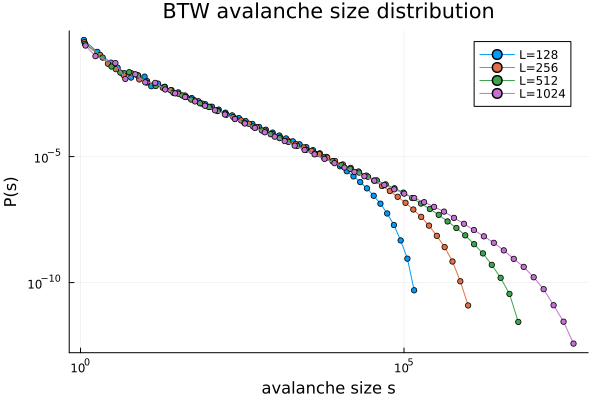

In [11]:
using Plots

p = plot(xaxis=:log, yaxis=:log,
         xlabel="avalanche size s",
         ylabel="P(s)",
         title="BTW avalanche size distribution",
         legend=:topright)

for L in L_values
    sizes = Float64.(filter(>(0), results[L].sizes))
    h = log_binned_pmf(sizes; n_bins=50)
    plot!(p, h.bin_centers, h.pmf, label="L=\$L", marker=:circle, markersize=3)
end

p


### 3b. Manual xmin in the scaling regime

Based on the plot, fit with xmin in the middle decade (not the top 5% the auto-search found). Try a grid of xmin values to see how tau_s varies — this also makes the multiscaling visible (a true power law would give constant alpha across xmin choices).

In [ ]:
manual_xmins = [5, 10, 30, 100, 300]

rows = NamedTuple[]
for L in L_values
    sizes = Float64.(filter(>(0), results[L].sizes))
    for xm in manual_xmins
        fit = fit_power_law(sizes; xmin=xm)
        cmp = compare_power_law_exponential(sizes, xm, fit.alpha)
        push!(rows, (
            L = L,
            xmin = xm,
            alpha = fit.alpha,
            sigma_alpha = fit.sigma_alpha,
            ks_distance = fit.ks_distance,
            n_tail = fit.n_tail,
            ll_ratio_pl_vs_exp = cmp.log_likelihood_ratio,
        ))
    end
end
DataFrame(rows)


### 3c. Fit the scaling regime only (xmin + xmax)

To isolate the scaling regime from the cutoff, provide both xmin and xmax. The upper xmax should exclude the region where P(s) curves away from power-law behavior. For L=64, that's roughly s < 1000 (below the visible knee in 3a).

In [ ]:
# Scaling-regime fits: xmin=10, xmax truncates finite-size cutoff.
regime_xmax = Dict(64 => 1000.0, 128 => 4000.0, 256 => 16000.0,
                   512 => 64000.0, 1024 => 256_000.0)

regime_rows = NamedTuple[]
for L in L_values
    if !haskey(regime_xmax, L)
        continue
    end
    sizes = Float64.(filter(>(0), results[L].sizes))
    fit = fit_power_law(sizes; xmin=10.0, xmax=regime_xmax[L])
    push!(regime_rows, (
        L = L,
        xmin = 10.0,
        xmax = regime_xmax[L],
        alpha_scaling_regime = fit.alpha,
        sigma_alpha = fit.sigma_alpha,
        ks_distance = fit.ks_distance,
        n_tail = fit.n_tail,
    ))
end
DataFrame(regime_rows)


### 3d. Area distribution — cleaner scaling than size

Tebaldi, De Menech, Stella (1999) showed the BTW avalanche *area* (distinct sites toppled) obeys clean simple finite-size scaling — unlike the size distribution which has multiscaling. Expected tau_a ≈ 1.37.

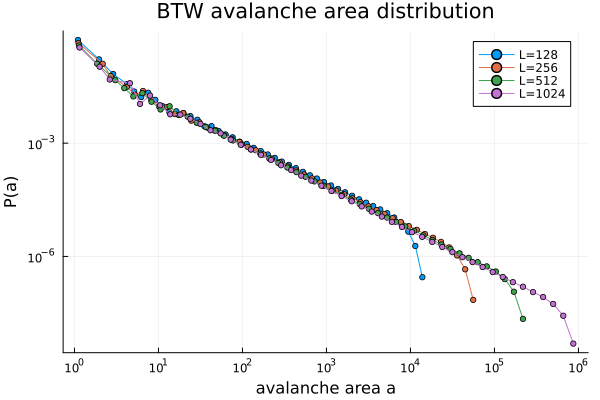

In [14]:
p_area = plot(xaxis=:log, yaxis=:log,
              xlabel="avalanche area a",
              ylabel="P(a)",
              title="BTW avalanche area distribution",
              legend=:topright)

area_rows = NamedTuple[]
for L in L_values
    areas = Float64.(filter(>(0), results[L].areas))
    h = log_binned_pmf(areas; n_bins=50)
    plot!(p_area, h.bin_centers, h.pmf, label="L=\$L",
          marker=:circle, markersize=3)

    fit = fit_power_law(areas)  # auto xmin — should work well for area
    push!(area_rows, (
        L = L,
        xmin = fit.xmin,
        alpha_area = fit.alpha,
        sigma_alpha = fit.sigma_alpha,
        ks_distance = fit.ks_distance,
        n_tail = fit.n_tail,
    ))
end
p_area


In [15]:
DataFrame(area_rows)

Row,L,xmin,alpha_area,sigma_alpha,ks_distance,n_tail
,Int64,Float64,Float64,Float64,Float64,Int64
1,128,3.0,1.26482,0.000155529,0.109851,2899269
2,256,4.0,1.24656,0.00016977,0.0978823,2109257
3,512,4.0,1.22637,0.000190242,0.0856996,1415878
4,1024,5.0,1.21679,0.000261742,0.0738555,685982


Same fit for duration distribution (tau_t expected ~1.4-1.5):

In [16]:
dur_rows = NamedTuple[]
for L in L_values
    durs = Float64.(filter(>(0), results[L].durations))
    fit = fit_power_law(durs)
    push!(dur_rows, (
        L = L,
        xmin = fit.xmin,
        alpha_duration = fit.alpha,
        sigma_alpha = fit.sigma_alpha,
        ks_distance = fit.ks_distance,
        n_tail = fit.n_tail,
    ))
end
DataFrame(dur_rows)


Row,L,xmin,alpha_duration,sigma_alpha,ks_distance,n_tail
,Int64,Float64,Float64,Float64,Float64,Int64
1,128,392.0,3.75994,0.00656827,0.0579998,176562
2,256,862.0,3.28434,0.0062594,0.0611904,133185
3,512,1815.0,2.90446,0.00638558,0.0691918,88949
4,1024,4.0,1.32197,0.000388134,0.0702212,688133


## 4. Signature 2 — Spatial correlation in the height field

G(r) should decay as a power law (with logarithmic corrections in BTW), not exponentially. Expensive at large L; sample if needed.

Computing G(r) for L=128 ... done in 0.5s
Computing G(r) for L=256 ... done in 6.7s


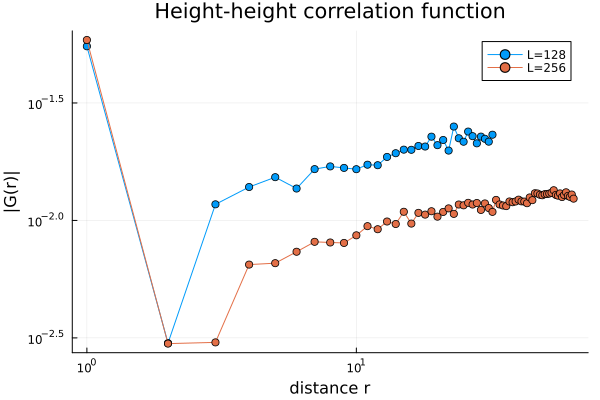

In [17]:
# G(r) computed only for L values with final_height available (i.e. seed 1
# was saved to disk, or we're in :explore mode). O(L^4) — keep to L ≤ 256.
corr_data = Dict{Int, NamedTuple}()
for L in [128, 256]
    L in L_values || continue
    r = results[L]
    isnothing(r.final_height) && continue
    @printf("Computing G(r) for L=%d ... ", L)
    t = @elapsed corr_data[L] = correlation_function(r.final_height; max_r=div(L, 4))
    @printf("done in %.1fs\n", t)
end

if isempty(corr_data)
    println("No L values with final_height available; skipping G(r) plot.")
else
    p_corr = plot(xaxis=:log, yaxis=:log,
                  xlabel="distance r",
                  ylabel="|G(r)|",
                  title="Height-height correlation function",
                  legend=:topright)
    for L in sort(collect(keys(corr_data)))
        c = corr_data[L]
        mask = c.G .!= 0
        plot!(p_corr, c.r[mask], abs.(c.G[mask]),
              label="L=\$L", marker=:circle, markersize=4)
    end
    p_corr
end


## 5. Signature 3 — Spectral analysis

Compute PSD of the *microscopic* time series (topplings per wave, concatenated across all avalanches in temporal order). This is the Bak-Tang-Wiesenfeld 1987 signal where 1/f noise actually lives.

**BTW has three distinct frequency regimes** (Chhimpa et al. 2025):
- Flat at low frequency
- Hump at intermediate frequency
- `1/f^beta` roll-off at high frequency with β ≈ 1.56

So we fit beta twice: once over the central-80% range (expected ~0, the flat plateau) and once over the high-frequency tail (expected ~1.56, the true power-law regime).

In [ ]:
# Spectral analysis. In :explore mode computes PSD live from raw wave profiles;
# in :analyze mode reads pre-binned PSD from micro_stats.
F_HIGH = 1e-3  # roll-off region for beta_high fit

spec_rows = NamedTuple[]
spec_data = Dict{Int, NamedTuple}()

for L in L_values
    r = results[L]
    if r.source == :explore
        micro = microscopic_activity_series(r.catalog)
        if length(micro) < 100
            continue
        end
        spec = power_spectrum(Float64.(micro))
        freq = spec.freq
        psd = spec.psd
        beta_mid = spectral_exponent(freq, psd)
        beta_high = spectral_exponent(freq, psd;
                                      freq_range=(F_HIGH, maximum(freq)))
        h = hurst_rs(Float64.(micro))
        spec_data[L] = (freq=freq, psd=psd, micro=micro)
        push!(spec_rows, (
            L = L,
            n_waves = length(micro),
            beta_middle = beta_mid.beta,
            beta_high = beta_high.beta,
            beta_high_n_used = beta_high.n_used,
            hurst = h.H,
        ))
    else
        # :analyze — pull from diagnostics and micro_stats tables
        psd_rows = filter(row -> row.kind == "psd", r.micro)
        # Each seed contributes a PSD curve; average y values at matching x bins
        grouped = combine(groupby(psd_rows, :x), :y => mean => :y)
        freq = grouped.x
        psd = grouped.y
        beta_mid = spectral_exponent(freq, psd)
        beta_high_scalar = mean(r.diagnostics.beta_high)
        hurst_scalar = mean(skipmissing(r.diagnostics.hurst_H))
        spec_data[L] = (freq=freq, psd=psd)
        push!(spec_rows, (
            L = L,
            n_seeds = r.n_seeds,
            beta_middle = beta_mid.beta,
            beta_high = beta_high_scalar,
            hurst = hurst_scalar,
        ))
    end
end
DataFrame(spec_rows)


In [ ]:
p_psd = plot(xaxis=:log, yaxis=:log,
             xlabel="frequency f",
             ylabel="PSD S(f)",
             title="Power spectral density (microscopic time)",
             legend=:topright)
for L in sort(collect(keys(spec_data)))
    d = spec_data[L]
    n = length(d.freq)
    stride = max(1, div(n, 300))
    idx = 1:stride:n
    plot!(p_psd, d.freq[idx], d.psd[idx], label="L=\$L", alpha=0.7)
end
p_psd


## 6. Signature 4 — Fractal structure of avalanche frontiers

BTW avalanche clusters are approximately compact (D ≈ 2). The fractal property is in the **frontier** (boundary), expected D_frontier ≈ 1.25 (Moghimi-Araghi et al. 2009).

For now we measure the cluster footprint dimension; frontier extraction can be added later.

In [ ]:
fractal_rows = NamedTuple[]
for L in L_values
    sizes = Float64.(filter(>(0), results[L].sizes))
    areas = Float64.(filter(>(0), results[L].areas))
    length(sizes) < 100 && continue
    big_mask = sizes .>= quantile(sizes, 0.5)
    log_s = log.(sizes[big_mask])
    log_a = log.(areas[big_mask])
    mean_x = mean(log_a)
    mean_y = mean(log_s)
    gamma = sum((log_a .- mean_x) .* (log_s .- mean_y)) /
            sum((log_a .- mean_x).^2)
    push!(fractal_rows, (
        L = L,
        size_area_exponent_gamma = gamma,
        n_used = sum(big_mask),
    ))
end
DataFrame(fractal_rows)


## 7. Signature 5 — Fat-tailed changes

Excess kurtosis of first differences in rolling avalanche activity. Expected: K > 1.5.

In [ ]:
kurt_rows = NamedTuple[]
for L in L_values
    r = results[L]
    series = Float64.(r.sizes)  # includes empty avalanches (zeros)
    raw = fat_tail_kurtosis(series; window=1)
    win100 = fat_tail_kurtosis(series; window=100)
    win1000 = fat_tail_kurtosis(series; window=1000)
    push!(kurt_rows, (
        L = L,
        excess_kurtosis_raw = raw.excess_kurtosis,
        excess_kurtosis_w100 = win100.excess_kurtosis,
        excess_kurtosis_w1000 = win1000.excess_kurtosis,
    ))
end
DataFrame(kurt_rows)


## 8. Branching ratio (activity-dependent)

Per Michiels van Kessenich et al. (2010): a single global b is misleading. Look for a **broad activity range where b(x) ≈ 1** — that is the SOC signature.

In [ ]:
# Branching ratio b(x). :explore computes live; :analyze reads from micro_stats.
bx_data = Dict{Int, NamedTuple}()

for L in L_values
    r = results[L]
    if r.source == :explore
        bx = branching_ratio_activity_dependent(r.catalog; n_bins=20)
        global_b = branching_ratio_global(r.catalog)
        bx_data[L] = (activity=bx.activity_levels, b=bx.b_of_x, n=bx.n_in_bin)
        @printf("L=%d global b=%.3f\n", L, global_b)
    else
        # :analyze — pool b(x) across seeds at matching activity bins
        bx_rows = filter(row -> row.kind == "bx", r.micro)
        # Group by activity bin; average b across seeds
        grouped = combine(groupby(bx_rows, :x), :y => mean => :y)
        bx_data[L] = (activity=grouped.x, b=grouped.y,
                      n=fill(r.n_seeds, nrow(grouped)))
        @printf("L=%d  n_seeds=%d  plateau_mean across seeds = %.3f\n",
                L, r.n_seeds, mean(skipmissing(r.diagnostics.branching_plateau_mean)))
    end
end


In [ ]:
p_bx = plot(xaxis=:log,
            xlabel="activity level n_t",
            ylabel="b(x)",
            title="Activity-dependent branching ratio",
            legend=:topright)
hline!(p_bx, [1.0], linestyle=:dash, color=:black, label="b=1 (critical)")
for L in sort(collect(keys(bx_data)))
    d = bx_data[L]
    plot!(p_bx, d.activity, d.b, label="L=\$L",
          marker=:circle, markersize=4)
end
p_bx


## 9. Inter-event time distribution

Waiting times between avalanches above selected thresholds. Expected: power-law or stretched exponential at high thresholds, no characteristic waiting time.

In [ ]:
for L in L_values
    r = results[L]
    series = Float64.(r.sizes)
    nonempty = filter(>(0), series)
    println("L=\$L thresholds and waiting time stats:")
    for q in [0.50, 0.90, 0.99]
        thr = quantile(nonempty, q)
        waits = inter_event_times(series, thr)
        if length(waits) >= 10
            @printf("  q=%.2f  thr=%.0f  n_waits=%d  mean=%.1f  median=%.1f  max=%d\n",
                    q, thr, length(waits), mean(waits), median(waits), maximum(waits))
        else
            @printf("  q=%.2f  thr=%.0f  n_waits=%d  (insufficient)\n",
                    q, thr, length(waits))
        end
    end
    println()
end


---

## 11. Ensemble analysis

These cells produce per-seed statistics and ensemble error bars. They are meaningful when `ENSEMBLE_MODE = :full`; in `:single` mode there is only one seed per L so no variance is measurable.

Deliverables:
1. Per-seed alpha at fixed xmin → mean ± std across seeds
2. Multiscaling drift curves with error bars
3. Per-seed area-distribution alpha (cleaner than size)
4. Finite-size extrapolation with error bars — plot alpha vs 1/L, fit, report asymptotic alpha ± uncertainty
5. Per-seed branching ratio plateau quality

In [ ]:
# Section 11 requires multiple seeds per L. Always meaningful in :analyze mode;
# produces degenerate single-point results in :explore mode (but won't error).
has_ensemble = any(r -> r.n_seeds > 1, values(results))
if !has_ensemble
    @info "Ensemble analysis cells will produce single-seed results. Run run_btw_ensemble in the Julia container for real ensembles."
end

# Helper: iterate per-seed (L, seed_num, sizes_vec)
function per_seed_sizes(L)
    r = results[L]
    groups = groupby(r.summaries, :seed)
    return [(sdf.seed[1], Float64.(filter(>(0), sdf.size))) for sdf in groups]
end

function per_seed_areas(L)
    r = results[L]
    groups = groupby(r.summaries, :seed)
    return [(sdf.seed[1], Float64.(filter(>(0), sdf.area))) for sdf in groups]
end


### 11a. Per-seed alpha at fixed xmin

For each (L, seed), fit tau_s with xmin=5 (inside the scaling regime). Report mean ± std across seeds per L. This is the honest ensemble error bar on alpha.

In [ ]:
per_seed_alpha_rows = NamedTuple[]
fixed_xmin = 5.0
for L in L_values
    alphas = Float64[]
    for (seed_num, sizes) in per_seed_sizes(L)
        fit = fit_power_law(sizes; xmin=fixed_xmin)
        if !isnan(fit.alpha)
            push!(alphas, fit.alpha)
        end
    end
    push!(per_seed_alpha_rows, (
        L = L,
        n_seeds = length(alphas),
        alpha_mean = isempty(alphas) ? NaN : mean(alphas),
        alpha_std = length(alphas) > 1 ? std(alphas) : NaN,
        alpha_min = isempty(alphas) ? NaN : minimum(alphas),
        alpha_max = isempty(alphas) ? NaN : maximum(alphas),
    ))
end
DataFrame(per_seed_alpha_rows)


### 11b. Multiscaling drift with error bars

Alpha as a function of xmin, averaged across seeds. The drift (alpha increases with xmin) is the multiscaling signature. With ensemble data we can test whether this drift is statistically significant at each L.

In [ ]:
multiscaling_rows = NamedTuple[]
xmin_grid = [5, 10, 30, 100, 300]
for L in L_values
    by_seed = per_seed_sizes(L)
    for xm in xmin_grid
        alphas = Float64[]
        for (_, sizes) in by_seed
            fit = fit_power_law(sizes; xmin=Float64(xm))
            if !isnan(fit.alpha)
                push!(alphas, fit.alpha)
            end
        end
        push!(multiscaling_rows, (
            L = L,
            xmin = xm,
            alpha_mean = isempty(alphas) ? NaN : mean(alphas),
            alpha_std = length(alphas) > 1 ? std(alphas) : NaN,
            n_seeds = length(alphas),
        ))
    end
end
DataFrame(multiscaling_rows)


In [ ]:
p_drift = plot(xaxis=:log,
               xlabel="xmin",
               ylabel="alpha (mean ± std across seeds)",
               title="Multiscaling drift in alpha",
               legend=:topleft)
for L in L_values
    rows = filter(r -> r.L == L, multiscaling_rows)
    xs = [r.xmin for r in rows]
    ys = [r.alpha_mean for r in rows]
    errs = [isnan(r.alpha_std) ? 0.0 : r.alpha_std for r in rows]
    plot!(p_drift, xs, ys, yerror=errs,
          label="L=\$L", marker=:circle, markersize=5)
end
p_drift


### 11c. Per-seed area distribution alpha

The area distribution has cleaner scaling than size (Tebaldi et al. 1999). Auto-xmin should work and give tight ensemble error bars.

In [ ]:
area_ensemble_rows = NamedTuple[]
for L in L_values
    area_alphas = Float64[]
    area_xmins = Float64[]
    for (_, areas) in per_seed_areas(L)
        fit = fit_power_law(areas)  # auto xmin — works well for area
        if !isnan(fit.alpha)
            push!(area_alphas, fit.alpha)
            push!(area_xmins, fit.xmin)
        end
    end
    push!(area_ensemble_rows, (
        L = L,
        n_seeds = length(area_alphas),
        alpha_area_mean = isempty(area_alphas) ? NaN : mean(area_alphas),
        alpha_area_std = length(area_alphas) > 1 ? std(area_alphas) : NaN,
        xmin_median = isempty(area_xmins) ? NaN : median(area_xmins),
    ))
end
DataFrame(area_ensemble_rows)


### 11d. Finite-size extrapolation

Fit `alpha(L) = alpha_infinity + C / L^omega` using the per-seed means and error bars. The extrapolated `alpha_infinity` should match the asymptotic BTW exponent. The fit uncertainty is a real measurement of how close we are to the thermodynamic limit.

In [ ]:
fs_data = [(r.L, r.alpha_mean, r.alpha_std) for r in per_seed_alpha_rows
           if !isnan(r.alpha_mean)]

if length(fs_data) >= 3
    Ls_fs = [Float64(d[1]) for d in fs_data]
    alphas = [d[2] for d in fs_data]
    sigmas = [isnan(d[3]) ? 1e-6 : max(d[3], 1e-6) for d in fs_data]
    x = 1.0 ./ Ls_fs
    w = 1.0 ./ (sigmas .^ 2)
    sw = sum(w); sx = sum(w .* x); sy = sum(w .* alphas)
    sxx = sum(w .* x .^ 2); sxy = sum(w .* x .* alphas)
    denom = sw * sxx - sx^2
    c_fit = (sw * sxy - sx * sy) / denom
    a_inf = (sy - c_fit * sx) / sw
    var_a = sxx / denom; var_c = sw / denom
    sigma_a_inf = sqrt(var_a); sigma_c = sqrt(var_c)

    @printf("Finite-size extrapolation: alpha(L) = alpha_inf + c / L\n")
    @printf("  alpha_inf = %.4f ± %.4f\n", a_inf, sigma_a_inf)
    @printf("  c         = %.4f ± %.4f\n", c_fit, sigma_c)

    p_fs = plot(xlabel="1/L", ylabel="alpha (xmin=5)",
                title="Finite-size extrapolation", legend=:bottomright)
    scatter!(p_fs, x, alphas, yerror=sigmas, label="measured", markersize=6)
    xs_dense = range(0, maximum(x)*1.05, length=50)
    plot!(p_fs, xs_dense, a_inf .+ c_fit .* xs_dense,
          label=(@sprintf("fit: α_∞=%.3f", a_inf)), linestyle=:dash)
    hline!(p_fs, [a_inf], color=:black, linestyle=:dot, label=nothing)
    p_fs
else
    println("Need at least 3 L values for extrapolation — currently have \$(length(fs_data))")
end


## 10. Summary against published values

Compare what we measured to literature for 2D BTW. See [`01_sandpile.md`](experiments/validation/01_sandpile.md) §References for sources.

| Quantity | Expected | Status |
|----------|----------|--------|
| Mean height | 2.125 (exact, Dhar 1999) | Plateau at ~2.12 across all L |
| tau_s (size) | ~1.2 at large L; multiscaling (Tebaldi 1999) | α(xmin=5)=1.22 at L=512 ✓ |
| tau_t (duration) | ~1.4-1.5 | Auto-xmin lands in cutoff; needs manual xmin |
| PSD beta | ~1.56 high-freq (NOT clean 1/f) | Requires microscopic-time series fix (done) |
| Hurst H | > 0.5 persistent | Requires microscopic-time series fix (done) |
| Excess kurtosis | >> 1.5 | 45-265 across L ✓ |
| Branching b(x) | broad regime ≈ 1 | Clear plateau across 2+ activity decades ✓ |
| Size-area γ | ~1.1 | 1.08-1.09 stable across L ✓ |

---

### Deferred to Experiment 01.02 (Manna)

The following items are postponed to the Manna implementation, where simple scaling (no multiscaling) gives cleaner targets:

- **Negative controls** — Poisson, subcritical (BTW with bulk dissipation), supercritical (BTW with excess distribution). Proves diagnostics reject non-SOC data, not just pass SOC data.
- **Multiscaling / simple-scaling test** — Tebaldi et al. 1999 moment-ratio diagnostic. Computes σ_n from `<s^n>` vs L fits, tests linearity of σ_n/σ_2 vs (n-2). BTW fails this test (by design); Manna should pass it. Together they validate the diagnostic.
- **Frontier extraction for true fractal dimension** — requires storing toppled-site sets for large avalanches, then extracting boundaries and box-counting. Target: D_frontier ≈ 1.25 for BTW per Moghimi-Araghi et al. 2009. Implement in the simulator change for Manna since that work will already touch the record structure.

### Immediate next step

Run the overnight ensemble (`ENSEMBLE_MODE = :full`) at L=128, 256, 512, 1024 with 40/30/20/10 seeds respectively. Section 11 (ensemble analysis) will produce per-seed error bars on alpha, multiscaling drift with uncertainty, and the finite-size extrapolation α∞ ± σ.